In [1]:
import pandas as pd
df = pd.read_csv("dataset_apel_600.csv")
df

,diameter,berat,tebal_kulit,kadar_gula,asal_daerah,warna,musim_panen,kualitas
0,5.94,143.20,0.67,10.60,Malang,kuning kemerahan,hujan,Sedang
1,7.23,246.59,0.80,12.18,Boyolali,merah,kemarau,Bagus
2,6.67,236.43,0.80,12.27,Boyolali,merah,kemarau,Bagus
3,6.58,168.04,0.78,11.02,Boyolali,kuning kemerahan,kemarau,Sedang
4,5.91,141.48,0.70,11.23,Malang,kuning kemerahan,kemarau,Sedang
...,...,...,...,...,...,...,...,...
595,7.45,251.27,0.90,14.00,Boyolali,merah,kemarau,Bagus
596,6.60,263.26,0.77,12.72,Malang,merah,kemarau,Bagus
597,5.99,101.44,0.53,8.30,Garut,hijau,hujan,Jelek
598,6.19,258.85,0.80,12.01,Malang,merah,kemarau,Bagus


In [2]:
df.shape

(600, 8)

In [3]:
df.columns

Index(['diameter', 'berat', 'tebal_kulit', 'kadar_gula', 'asal_daerah',
       'warna', 'musim_panen', 'kualitas'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diameter     600 non-null    float64
 1   berat        600 non-null    float64
 2   tebal_kulit  600 non-null    float64
 3   kadar_gula   600 non-null    float64
 4   asal_daerah  600 non-null    str    
 5   warna        600 non-null    str    
 6   musim_panen  600 non-null    str    
 7   kualitas     600 non-null    str    
dtypes: float64(4), str(4)
memory usage: 53.3 KB


In [5]:
df.describe()

,diameter,berat,tebal_kulit,kadar_gula
count,600.000000,600.000000,600.000000,600.000000
mean,6.351500,176.898683,0.738417,11.571550
std,0.548116,52.434347,0.117873,1.830502
min,5.140000,70.900000,0.500000,8.300000
25%,5.950000,133.395000,0.657500,10.050000
50%,6.200000,168.040000,0.730000,11.230000
75%,6.670000,232.880000,0.850000,13.250000
max,7.830000,283.690000,0.970000,14.930000


In [6]:
df["asal_daerah"].value_counts()

asal_daerah
Malang      280
Garut       167
Boyolali    153
Name: count, dtype: int64

In [7]:
df["warna"].value_counts()

warna
kuning kemerahan    226
merah               212
hijau               162
Name: count, dtype: int64

In [8]:
df["musim_panen"].value_counts()

musim_panen
kemarau    324
hujan      276
Name: count, dtype: int64

In [9]:
df["kualitas"].value_counts()

kualitas
Sedang    224
Bagus     223
Jelek     153
Name: count, dtype: int64

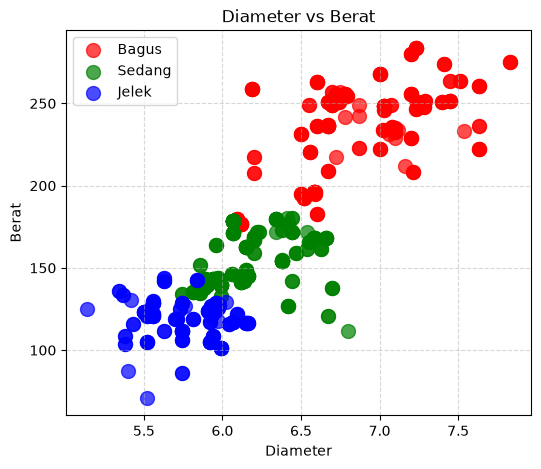

In [10]:
import matplotlib.pyplot as plt
bagus = df[df["kualitas"] == "Bagus"]
sedang = df[df["kualitas"] == "Sedang"]
jelek = df[df["kualitas"] == "Jelek"]
plt.figure(figsize=(6, 5))
plt.scatter(bagus["diameter"], bagus["berat"], s=100, alpha=0.7, color="red", label="Bagus")
plt.scatter(sedang["diameter"], sedang["berat"], s=100, alpha=0.7, color="green", label="Sedang")
plt.scatter(jelek["diameter"], jelek["berat"], s=100, alpha=0.7, color="blue", label="Jelek")
plt.title("Diameter vs Berat")
plt.xlabel("Diameter")
plt.ylabel("Berat")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

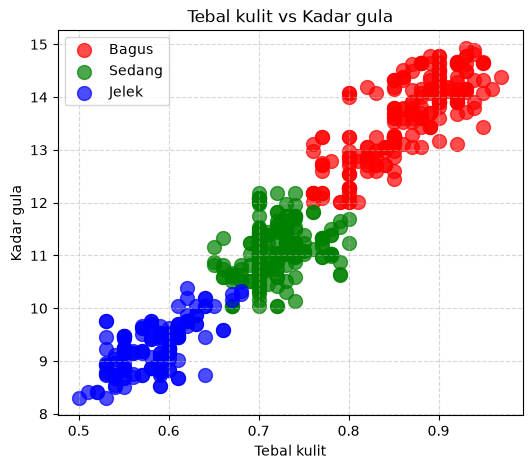

In [11]:
import matplotlib.pyplot as plt
bagus = df[df["kualitas"] == "Bagus"]
sedang = df[df["kualitas"] == "Sedang"]
jelek = df[df["kualitas"] == "Jelek"]
plt.figure(figsize=(6, 5))
plt.scatter(bagus["tebal_kulit"], bagus["kadar_gula"], s=100, alpha=0.7, color="red", label="Bagus")
plt.scatter(sedang["tebal_kulit"], sedang["kadar_gula"], s=100, alpha=0.7, color="green", label="Sedang")
plt.scatter(jelek["tebal_kulit"], jelek["kadar_gula"], s=100, alpha=0.7, color="blue", label="Jelek")
plt.title("Tebal kulit vs Kadar gula")
plt.xlabel("Tebal kulit")
plt.ylabel("Kadar gula")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

X = df[['diameter', 'berat', 'tebal_kulit', 'kadar_gula', 'asal_daerah', 'warna', 'musim_panen']]
y = df['kualitas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_columns = ['diameter', 'berat', 'tebal_kulit', 'kadar_gula']
categorical_columns = ['asal_daerah']
ordinal_columns = ['warna']

warna_order = ['hijau', 'kuning kemerahan', 'merah']
ordinal_order = [warna_order]

preprocessing = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), numeric_columns),
        ('ohe', OneHotEncoder(), categorical_columns),
        ('oe', OrdinalEncoder(categories=ordinal_order), ordinal_columns)
    ]
)

model = Pipeline(
    steps=[
        ('preprocessing', preprocessing),
        ('model', LogisticRegression())
    ]
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(f"accuracy:\n{accuracy_score(y_test, y_pred)}")
print(f"\nclassification report:\n{classification_report(y_test, y_pred)}")
print(f"\nconfusion matrix:\n{confusion_matrix(y_test, y_pred)}")

accuracy:
1.0

classification report:
              precision    recall  f1-score   support

       Bagus       1.00      1.00      1.00        48
       Jelek       1.00      1.00      1.00        29
      Sedang       1.00      1.00      1.00        43

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120


confusion matrix:
[[48  0  0]
 [ 0 29  0]
 [ 0  0 43]]


In [15]:
import joblib as jb
jb.dump(model, 'apple_model.joblib')

['apple_model.joblib']